In [ ]:
Name : Ragini Singh
Cohort : JH
Roll No : 150096724023
Assignment : 04

# Cybersecurity Dataset Analysis and Machine Learning

## Objective

The objective of this assignment is to analyze a cybersecurity-related dataset and build machine learning models for cybersecurity attack detection.

### Tasks Performed

1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Data Visualization
4. Implementation of Four Machine Learning Algorithms
5. Algorithm Comparison
6. Final Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("cybersecurity_dataset")

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [3]:
for root, dirs, files_list in os.walk("cybersecurity_dataset"):
    for file in files_list:
        print(os.path.join(root, file))

cybersecurity_dataset/cybersecurity_intrusion_data.csv


## 1. Dataset Loading

The cybersecurity dataset is loaded using Pandas. The dataset contains network-based and user-behavior-based features that can be used to detect potential cyber attacks.

In [4]:
import pandas as pd

df = pd.read_csv("cybersecurity_dataset/cybersecurity_intrusion_data.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 2. Understanding the Dataset

Before performing data cleaning and analysis, we inspect the structure, dimensions, data types, and statistical summary of the dataset.

In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 9537
Number of Columns: 11

Column Names:
['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [8]:
df.describe(include="all")

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
count,9537,9537.000000,9537,9537.000000,9537.000000,7571,9537.000000,9537.000000,9537,9537.000000,9537.000000
unique,9537,NaN,3,NaN,NaN,2,NaN,NaN,5,NaN,NaN
top,SID_09537,NaN,TCP,NaN,NaN,AES,NaN,NaN,Chrome,NaN,NaN
freq,1,NaN,6624,NaN,NaN,4706,NaN,NaN,5137,NaN,NaN
mean,NaN,500.430639,NaN,4.032086,792.745312,NaN,0.331338,1.517773,NaN,0.149942,0.447101
std,NaN,198.379364,NaN,1.963012,786.560144,NaN,0.177175,1.033988,NaN,0.357034,0.497220
min,NaN,64.000000,NaN,1.000000,0.500000,NaN,0.002497,0.000000,NaN,0.000000,0.000000
25%,NaN,365.000000,NaN,3.000000,231.953006,NaN,0.191946,1.000000,NaN,0.000000,0.000000
50%,NaN,499.000000,NaN,4.000000,556.277457,NaN,0.314778,1.000000,NaN,0.000000,0.000000
75%,NaN,635.000000,NaN,5.000000,1105.380602,NaN,0.453388,2.000000,NaN,0.000000,1.000000


In [9]:
df.head(10)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


## 3. Data Cleaning

Data cleaning is performed to identify and handle missing values, duplicate records, and inappropriate data types. This helps improve the quality and reliability of the machine learning model.

In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1966


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (9537, 11)


In [14]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']

Categorical columns:
['session_id', 'protocol_type', 'encryption_used', 'browser_type']


In [15]:
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64


### Data Cleaning Result

Numerical missing values were replaced using the median, while categorical missing values were replaced using the mode. Median is useful for numerical features because it is less affected by extreme values.

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics, distributions, relationships, and patterns present in the cybersecurity dataset.

In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9537
Columns: 11


In [17]:
df.dtypes

,0
session_id,object
network_packet_size,int64
protocol_type,object
login_attempts,int64
session_duration,float64
encryption_used,object
ip_reputation_score,float64
failed_logins,int64
browser_type,object
unusual_time_access,int64


In [18]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

session_id: 9537 unique values
network_packet_size: 959 unique values
protocol_type: 3 unique values
login_attempts: 13 unique values
session_duration: 9532 unique values
encryption_used: 2 unique values
ip_reputation_score: 9537 unique values
failed_logins: 6 unique values
browser_type: 5 unique values
unusual_time_access: 2 unique values
attack_detected: 2 unique values


attack_detected

In [19]:
print(df["attack_detected"].value_counts())

attack_detected
0    5273
1    4264
Name: count, dtype: int64


In [20]:
print(df["attack_detected"].value_counts(normalize=True) * 100)

attack_detected
0    55.289923
1    44.710077
Name: proportion, dtype: float64


## 5. Data Visualization

Different plots are used to visualize the distribution of cyber attacks, numerical features, categorical features, and relationships between variables.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

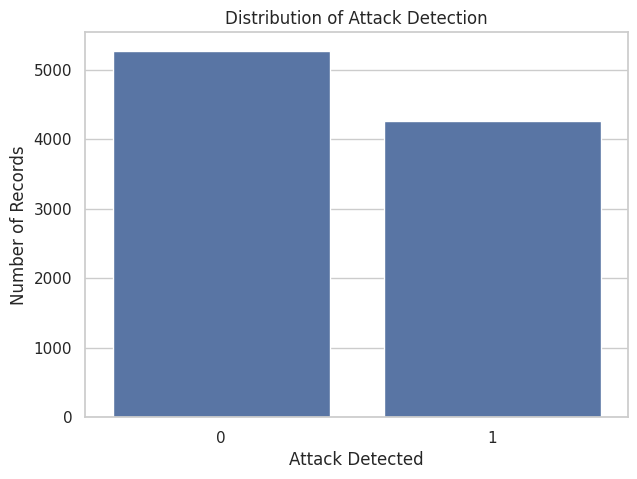

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="attack_detected")

plt.title("Distribution of Attack Detection")
plt.xlabel("Attack Detected")
plt.ylabel("Number of Records")

plt.show()

### Observation

The count plot shows the distribution of normal and attack records in the dataset. It helps us understand whether the target classes are balanced or imbalanced.

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="protocol_type")

plt.title("Distribution of Network Protocols")
plt.xlabel("Protocol Type")
plt.ylabel("Number of Records")

plt.show()

### Observation

This visualization shows the frequency of different communication protocols used in the network traffic. It helps identify which protocols are most common in the dataset.

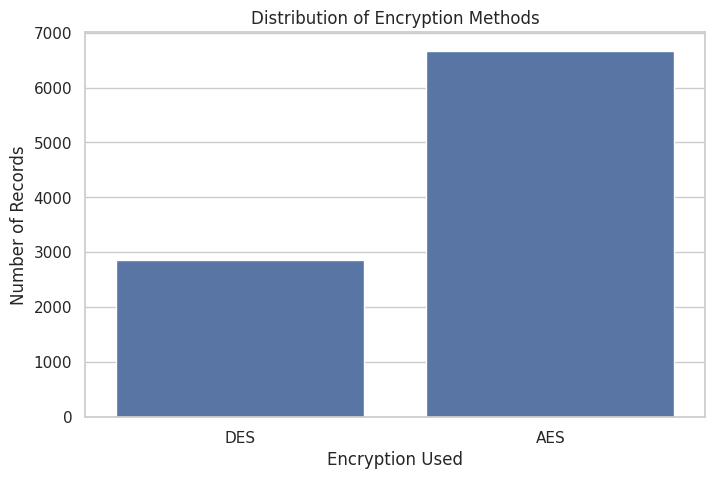

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="encryption_used")

plt.title("Distribution of Encryption Methods")
plt.xlabel("Encryption Used")
plt.ylabel("Number of Records")

plt.show()

### Observation

The plot shows the distribution of encryption methods. It helps us understand how different encryption methods are represented in the cybersecurity data.

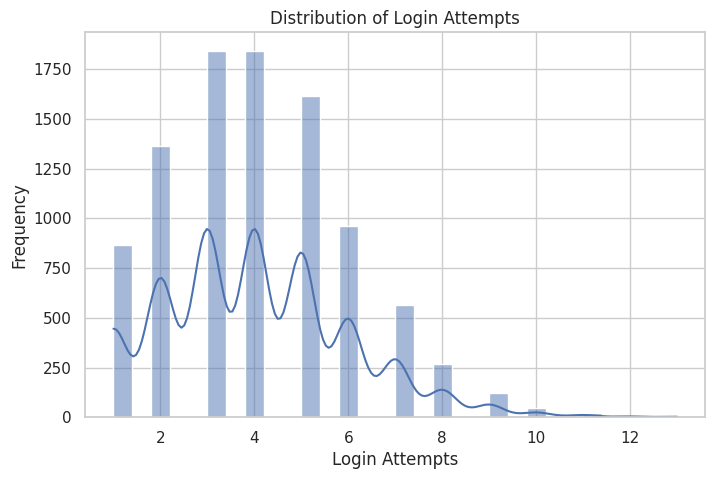

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="login_attempts", bins=30, kde=True)

plt.title("Distribution of Login Attempts")
plt.xlabel("Login Attempts")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of login attempts. A high number of login attempts may indicate suspicious behavior such as brute-force activity.

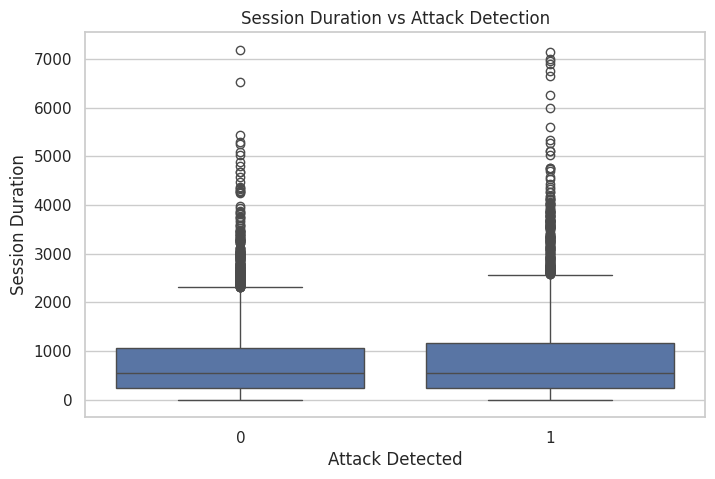

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="attack_detected",
    y="session_duration"
)

plt.title("Session Duration vs Attack Detection")
plt.xlabel("Attack Detected")
plt.ylabel("Session Duration")

plt.show()

### Observation

The box plot compares session duration between normal and detected attack records. Differences in the distributions may indicate that session duration contains useful information for attack detection.

## 6. Machine Learning Model Development

The dataset is prepared for binary classification, where the target variable `attack_detected` represents whether a cyber attack was detected.

Four machine learning algorithms are implemented and their performances are compared.

In [26]:
X = df.drop("attack_detected", axis=1)
y = df["attack_detected"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access']

Target:
attack_detected


In [27]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (9537, 9549)


## 7. Train-Test Split

The dataset is divided into training and testing sets. The training data is used to learn patterns, while the testing data is used to evaluate the model on unseen data.

80% of the data is used for training and 20% is used for testing.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7629, 9549)
Testing data: (1908, 9549)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Algorithm 1 — Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict binary outcomes. It is used as a baseline model for cybersecurity attack detection.

In [30]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

## 9. Algorithm 2 — Decision Tree

Decision Tree is a supervised learning algorithm that makes predictions using a sequence of decision rules. It is easy to interpret and can capture non-linear relationships.

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

## 10. Algorithm 3 — Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It generally provides strong performance on structured classification datasets.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## 11. Algorithm 4 — K-Nearest Neighbors

K-Nearest Neighbors classifies a data point based on the classes of nearby data points. Feature scaling is performed before applying KNN.

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

## 12. Algorithm Comparison

The four algorithms are evaluated using Accuracy, Precision, Recall, and F1-score.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Algorithm": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

results = []

results.append(
    evaluate_model("Logistic Regression", y_test, logistic_pred)
)

results.append(
    evaluate_model("Decision Tree", y_test, dt_pred)
)

results.append(
    evaluate_model("Random Forest", y_test, rf_pred)
)

results.append(
    evaluate_model("KNN", y_test, knn_pred)
)

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.735325,0.765244,0.588511,0.665341
1,Decision Tree,0.882600,0.987597,0.746776,0.850467
2,Random Forest,0.886268,1.000000,0.745604,0.854265
3,KNN,0.765723,0.741093,0.731536,0.736283


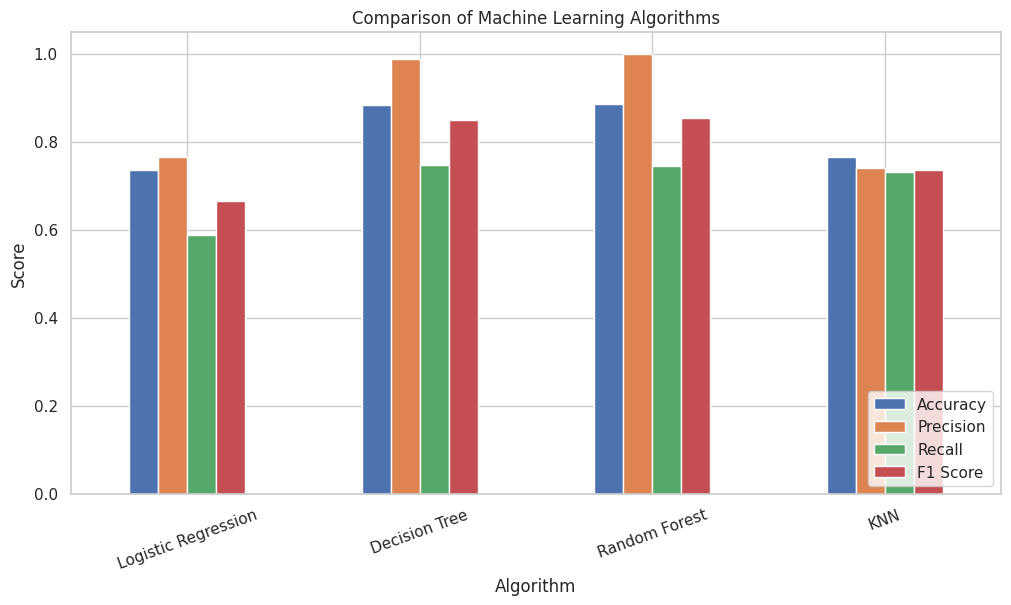

In [35]:
results_plot = results_df.set_index("Algorithm")

results_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)

plt.legend(loc="lower right")

plt.show()

In [36]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Performing Algorithm:")
print(best_model)

Best Performing Algorithm:
Algorithm    Random Forest
Accuracy          0.886268
Precision              1.0
Recall            0.745604
F1 Score          0.854265
Name: 2, dtype: object


## 13. Confusion Matrix

A confusion matrix is used to understand the classification performance of the machine learning models by showing correct and incorrect predictions.


 Logistic Regression


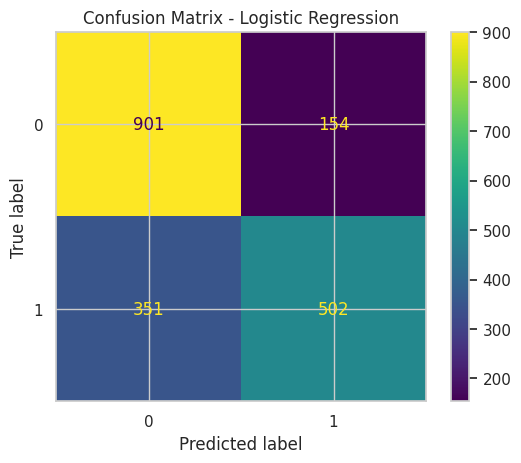


 Decision Tree


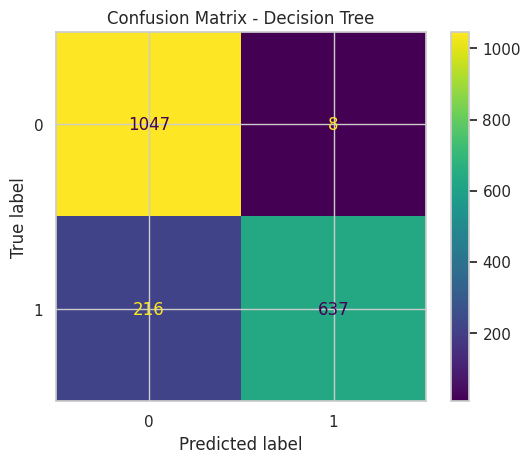


 Random Forest


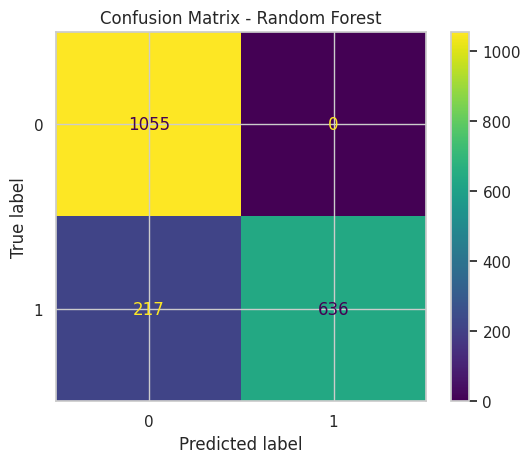


 KNN


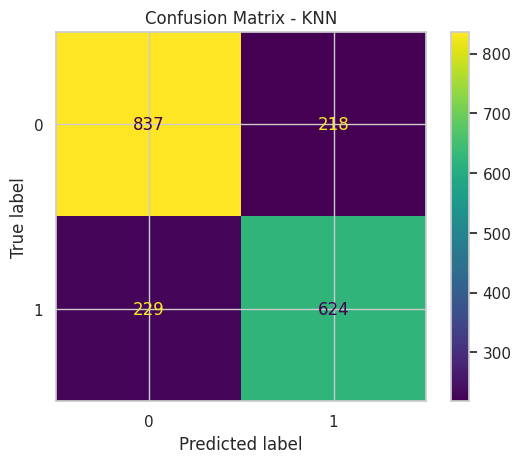

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (logistic_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "KNN": (knn_model, X_test_scaled)
}

for name, (model, test_data) in models.items():

    print("\n", name)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(test_data)
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## 14. Feature Importance

Random Forest provides feature importance values that help identify which features contribute most to cybersecurity attack detection.

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,failed_logins,0.237183
1,login_attempts,0.169241
3,ip_reputation_score,0.126033
2,session_duration,0.028610
0,network_packet_size,0.023572
9548,browser_type_Unknown,0.019372
9544,encryption_used_DES,0.003129
5,unusual_time_access,0.003013
9542,protocol_type_TCP,0.002232
9546,browser_type_Firefox,0.002054


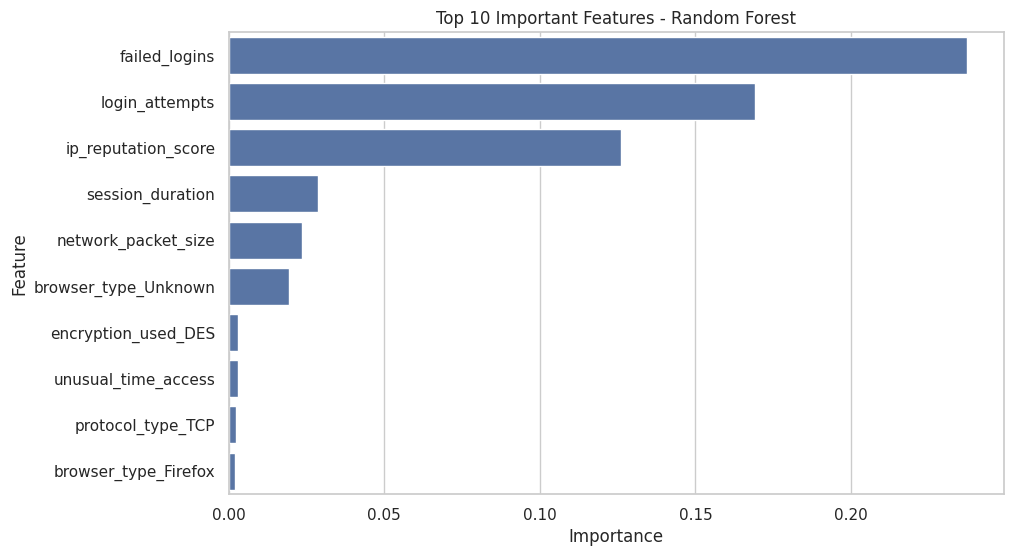

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [40]:
print(results_df)

             Algorithm  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.735325   0.765244  0.588511  0.665341
1        Decision Tree  0.882600   0.987597  0.746776  0.850467
2        Random Forest  0.886268   1.000000  0.745604  0.854265
3                  KNN  0.765723   0.741093  0.731536  0.736283


# 15. Final Conclusion

In this assignment, a cybersecurity intrusion detection dataset was analyzed
using Python and Machine Learning techniques.

The dataset was first cleaned by checking for missing values and duplicate
records. Exploratory Data Analysis was then performed to understand the
structure and characteristics of the data.

Multiple visualizations were created to study attack distribution, network
protocols, encryption methods, login attempts, session duration, and
correlations between numerical features.

Four machine learning algorithms were implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)

The models were evaluated using Accuracy, Precision, Recall, and F1-score.
The algorithm with the highest F1-score provided the best overall balance
between correctly identifying attacks and minimizing incorrect predictions.

Based on the experimental results, the best-performing model was selected
for cybersecurity attack detection.

This analysis demonstrates how Machine Learning can be applied to
cybersecurity data to identify patterns associated with malicious activity
and support intrusion detection systems.